# ScienceQA Visual Challenge: Starter Notebook

This notebook provides a starting point for the ScienceQA Visual Multiple-Choice Challenge. It is based on the provided baseline solution, but has been adapted to be more of a general-purpose starter.

**Objective:** Build a model that can answer visual multiple-choice questions based on scientific diagrams and text.

**Baseline Model:** `HuggingFaceTB/SmolVLM-500M-Instruct` (~500 M params)
**Fine-Tuning:** LoRA on attention + MLP projections, base model in `fp16`
**Scoring:** Multiple-choice log-likelihood

---

In [1]:
# ── 0. Install libraries ──────────────────────────────────────────
# Run this cell to install the necessary Python packages.
!pip install -q transformers==4.57.6 peft==0.18.1 bitsandbytes accelerate datasets pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.0 MB/s eta 0:00:00


In [2]:
# ── 1. Imports & Configuration ───────────────────────────────────────────────
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
# Adjust these paths to match your local environment
DATA_DIR   = Path("/kaggle/input/competitions/pixels-to-predictions")
OUT_DIR  = Path("/kaggle/working")            # where submission.csv will be written
CKPT_DIR = Path("/kaggle/working/lora_ckpt")    # where LoRA weights are saved
CKPT_DIR.mkdir(exist_ok=True, parents=True)

# ── Model ────────────────────────────────────────────────────────────────────
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE         = 384          # SmolVLM was trained at 384; keeps tokenization consistent
LORA_R           = 8            # rank — small enough to stay under 5M trainable params
LORA_ALPHA       = 16
LORA_DROPOUT     = 0.05
NUM_EPOCHS       = 2            # 1–2 is plenty for a small LoRA on this task
TRAIN_BATCH_SIZE = 1            # 4-bit + 384px images → keep small
GRAD_ACCUM_STEPS = 8            # effective batch ≈ 8
LR               = 3e-4
WARMUP_RATIO     = 0.03
WEIGHT_DECAY     = 0.0
MAX_TEXT_LEN     = 1024         # truncate long lectures
EVAL_BATCH_SIZE  = 1            # log-likelihood scoring is cheap per choice

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 2. Load and Preprocess Data

In [3]:
# ── 2a. Load CSVs ─────────────────────────────────────────────────────────────
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

# The 'choices' column is a JSON string, so we parse it
for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(json.loads)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
train_df.head(2)

Train: 3,109 | Val: 1,048 | Test: 1,008


,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill
0,train_07667,images/train/train_07667.png,Why might putting each tadpole in its own pool...,[the male's tadpoles will be larger when they ...,3,2,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
1,train_02628,images/train/train_02628.png,Why might forming strong social bonds with oth...,"[the female's offspring will live longer, the ...",3,0,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...


In [4]:
# ── 2b. Prompt Engineering ───────────────────────────────────────────────────
CHOICE_LETTERS = "ABCDEFGHIJ"

def build_prompt(row: pd.Series, include_answer: bool = False) -> str:
    """
    Builds the text prompt for the Vision Language Model.
    The <image> token is required for the model to process the image.
    """
    context_parts = []
    lecture = row.get("lecture", "")
    hint    = row.get("hint", "")
    if pd.notna(lecture) and str(lecture).strip():
        context_parts.append(str(lecture).strip())
    if pd.notna(hint) and str(hint).strip():
        context_parts.append(str(hint).strip())
    context_str = "\n".join(context_parts)

    choices = row["choices"]
    choices_str = "\n".join(
        f"  {CHOICE_LETTERS[i]}. {c}" for i, c in enumerate(choices)
    )

    prompt = "<image>\n"
    if context_str:
        prompt += f"Context:\n{context_str}\n\n"
    prompt += f"Question: {row['question']}\n"
    prompt += f"Choices:\n{choices_str}\n"
    prompt += "Answer:"

    if include_answer:
        answer_idx = int(row['answer'])
        prompt += f" {CHOICE_LETTERS[answer_idx]}"

    return prompt

# Display an example prompt
print(build_prompt(train_df.iloc[0], include_answer=True))

<image>
Context:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting them. For example, animals may feed their offspring or guard them from predators. These behaviors increase the chances that the offspring will survive to adulthood, when they can reproduce.
Many behaviors can increase the chances that animals will have offspring that survive to reproduce. But the behaviors cannot guarantee that the animals will have greater reproductive success. Animals that attract or compete for mates won't always successful

In [5]:
# ── 2c. PyTorch Dataset ───────────────────────────────────────────────────────
class ScienceQADataset(Dataset):
    def __init__(self, df: pd.DataFrame, data_dir: Path, img_size: int = 224, is_train: bool = True):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.img_size = img_size
        self.is_train = is_train

    def __len__(self) -> int:
        return len(self.df)

    def _load_image(self, rel_path: str) -> Image.Image:
        # CSV says "images/val/foo.png" but actual layout is "images/images/val/foo.png"
        p = self.data_dir / "images" / rel_path
        img = Image.open(p).convert("RGB")
        img = img.resize((self.img_size, self.img_size), Image.BICUBIC)
        return img

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]
        img = self._load_image(row["image_path"])

        if self.is_train:
            return {
                "image":  img,
                "text":   build_prompt(row, include_answer=True),
                "answer": int(row["answer"]),
            }
        else:
            return {
                "image":   img,
                "text":    build_prompt(row, include_answer=False),
                "choices": row["choices"],
                "answer":  int(row["answer"]) if "answer" in row else -1,
            }

train_ds = ScienceQADataset(train_df, DATA_DIR, img_size=IMG_SIZE, is_train=True)
val_ds   = ScienceQADataset(val_df,   DATA_DIR, img_size=IMG_SIZE, is_train=False)
test_ds  = ScienceQADataset(test_df,  DATA_DIR, img_size=IMG_SIZE, is_train=False)

print(f"Datasets created: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

Datasets created: train=3109, val=1048, test=1008


## 3. Model Loading and Inference Example

This section loads `HuggingFaceTB/SmolVLM-500M-Instruct` and runs a quick inference example on one validation sample.

In [6]:
# ── 3a. Load SmolVLM model + run one inference example ───────────────────────
from transformers import AutoProcessor, AutoModelForVision2Seq

processor = AutoProcessor.from_pretrained(MODEL_ID)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

dtype = torch.float16 if torch.cuda.is_available() else torch.float32
model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto" if torch.cuda.is_available() else None,
    low_cpu_mem_usage=True,
 )
if not torch.cuda.is_available():
    model.to(device)
model.eval()

# Pick a sample from validation set
sample = val_df.iloc[0]
sample_image = Image.open(DATA_DIR / "images" / sample["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
sample_prompt = build_prompt(sample, include_answer=False)

inputs = processor(
    text=[sample_prompt],
    images=[sample_image],
    return_tensors="pt",
)
inputs = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in inputs.items()}

with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,
    )

decoded = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Prompt:")
print(sample_prompt)
print("\nModel output:")
print(decoded)
print(f"\nGround-truth answer index: {sample['answer']}")

2026-05-06 18:36:12.238213: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778092572.481160      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778092572.544327      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778092573.067534      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778092573.067580      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778092573.067583      23 computation_placer.cc:177] computation placer alr

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Prompt:
<image>
Context:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting them. For example, animals may feed their offspring or guard them from predators. These behaviors increase the chances that the offspring will survive to adulthood, when they can reproduce.
Many behaviors can increase the chances that animals will have offspring that survive to reproduce. But the behaviors cannot guarantee that the animals will have greater reproductive success. Animals that attract or compete for mates won't always su

In [7]:
# ── 3b. Attach LoRA adapters and fine-tune on answer letters ──────────────────
from peft import LoraConfig, get_peft_model, TaskType
from transformers import get_scheduler
from tqdm.auto import tqdm

# Important for long prompts: keep the answer at the end if truncation is needed.
processor.tokenizer.truncation_side = "left"
processor.tokenizer.padding_side = "right"


def get_model_input_device(model):
    """Return the device where input tensors should be placed."""
    return next(model.parameters()).device


def move_inputs_to_device(inputs: dict, device: torch.device) -> dict:
    """Move tensor inputs to the model's input device."""
    return {
        k: v.to(device) if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }


def infer_lora_target_modules(model, verbose=True):
    preferred_leaf_names = {
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
        "fc1", "fc2", "dense", "out_proj",
        "qkv", "query_key_value",
    }

    found = set()
    candidates = []

    for module_name, module in model.named_modules():
        leaf_name = module_name.split(".")[-1]
        class_name = module.__class__.__name__.lower()

        looks_linear = (
            "linear" in class_name
            or "4bit" in class_name
            or "8bit" in class_name
        )

        if looks_linear:
            candidates.append((module_name, module.__class__.__name__))
            if leaf_name in preferred_leaf_names:
                found.add(leaf_name)

    if verbose:
        print("First linear-like modules found:")
        for name, cls in candidates[:40]:
            print(f"  {name}  [{cls}]")
        print(f"Total linear-like modules found: {len(candidates)}")

    if not found:
        raise ValueError(
            "Could not infer LoRA target modules. Look at the printed module names "
            "and set LORA_TARGET_MODULES manually."
        )

    return sorted(found)


LORA_TARGET_MODULES = infer_lora_target_modules(model)
print("LoRA target modules:", LORA_TARGET_MODULES)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


def load_competition_image(row: pd.Series, img_size: int = IMG_SIZE) -> Image.Image:
    return Image.open(DATA_DIR / "images" / row["image_path"]).convert("RGB").resize(
        (img_size, img_size), Image.BICUBIC
    )


def encode_training_example(row: pd.Series) -> dict:
    """
    Build one training example.

    The labels mask out everything except the final answer letter, so the model is
    trained to predict the correct multiple-choice letter rather than to reproduce
    the whole prompt.
    """
    image = load_competition_image(row)
    prompt = build_prompt(row, include_answer=False)
    answer_text = " " + CHOICE_LETTERS[int(row["answer"])]
    full_text = prompt + answer_text

    inputs = processor(
        text=[full_text],
        images=[image],
        padding=True,
        truncation=False,
        max_length=MAX_TEXT_LEN,
        return_tensors="pt",
    )

    labels = inputs["input_ids"].clone()

    # Mask all tokens except the answer suffix. This is more robust than using
    # prompt length when left truncation is enabled.
    answer_ids = processor.tokenizer(answer_text, add_special_tokens=False).input_ids
    answer_len = max(1, len(answer_ids))
    actual_len = int(inputs["attention_mask"][0].sum().item())
    answer_start = max(0, actual_len - answer_len)

    labels[0, :answer_start] = -100
    labels[0, actual_len:] = -100
    inputs["labels"] = labels
    return inputs


def train_lora(
    train_df: pd.DataFrame,
    max_train_examples: int | None = None,
    log_every: int = 25,
):
    """
    Fine-tune LoRA adapters using gradient accumulation.

    Set max_train_examples to a small number first, such as 64 or 128, to verify
    that the loss moves and the cell runs under your GPU memory limit. Then set
    it to None for the full training set.
    """
    model.train()
    train_data = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    if max_train_examples is not None:
        train_data = train_data.iloc[:max_train_examples].reset_index(drop=True)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

    updates_per_epoch = max(1, int(np.ceil(len(train_data) / GRAD_ACCUM_STEPS)))
    total_updates = updates_per_epoch * NUM_EPOCHS
    warmup_steps = int(WARMUP_RATIO * total_updates)
    scheduler = get_scheduler(
        name="linear",
        optimizer=optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_updates,
    )

    device = get_model_input_device(model)
    global_step = 0
    running_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for epoch in range(NUM_EPOCHS):
        pbar = tqdm(train_data.iterrows(), total=len(train_data), desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}")
        for step, (_, row) in enumerate(pbar, start=1):
            batch = encode_training_example(row)
            batch = move_inputs_to_device(batch, device)

            outputs = model(**batch)
            raw_loss = outputs.loss
            loss = raw_loss / GRAD_ACCUM_STEPS
            loss.backward()

            running_loss += float(raw_loss.detach().cpu())

            should_update = (step % GRAD_ACCUM_STEPS == 0) or (step == len(train_data))
            if should_update:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                global_step += 1

                if global_step % log_every == 0:
                    avg_loss = running_loss / (log_every * GRAD_ACCUM_STEPS)
                    pbar.set_postfix({"loss": f"{avg_loss:.4f}", "lr": scheduler.get_last_lr()[0]})
                    running_loss = 0.0

    model.eval()
    model.save_pretrained(CKPT_DIR)
    print(f"Saved LoRA adapter to: {CKPT_DIR}")


# Start with a small smoke test. If it runs and the loss is finite, change this to None.
# Example progression:
#   train_lora(train_df, max_train_examples=64)
#   val_acc_small, _, _ = evaluate_loglik(val_df, max_examples=25)
#   train_lora(train_df, max_train_examples=None)
#
# Uncomment to train:
train_lora(train_df, max_train_examples=64)


First linear-like modules found:
  model.vision_model.encoder.layers.0.self_attn.k_proj  [Linear]
  model.vision_model.encoder.layers.0.self_attn.v_proj  [Linear]
  model.vision_model.encoder.layers.0.self_attn.q_proj  [Linear]
  model.vision_model.encoder.layers.0.self_attn.out_proj  [Linear]
  model.vision_model.encoder.layers.0.mlp.fc1  [Linear]
  model.vision_model.encoder.layers.0.mlp.fc2  [Linear]
  model.vision_model.encoder.layers.1.self_attn.k_proj  [Linear]
  model.vision_model.encoder.layers.1.self_attn.v_proj  [Linear]
  model.vision_model.encoder.layers.1.self_attn.q_proj  [Linear]
  model.vision_model.encoder.layers.1.self_attn.out_proj  [Linear]
  model.vision_model.encoder.layers.1.mlp.fc1  [Linear]
  model.vision_model.encoder.layers.1.mlp.fc2  [Linear]
  model.vision_model.encoder.layers.2.self_attn.k_proj  [Linear]
  model.vision_model.encoder.layers.2.self_attn.v_proj  [Linear]
  model.vision_model.encoder.layers.2.self_attn.q_proj  [Linear]
  model.vision_model.enc

Epoch 1/2:   0%|          | 0/64 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2919: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Epoch 2/2:   0%|          | 0/64 [00:00<?, ?it/s]

Saved LoRA adapter to: /kaggle/working/lora_ckpt


In [8]:
# ── 4a. Multiple-choice log-likelihood scoring ──────────────────────────────
from tqdm.auto import tqdm

# Use the first real parameter device. This is safer than assuming model.device exists.
def get_model_input_device(model):
    return next(model.parameters()).device


def move_inputs_to_device(inputs: dict, device: torch.device) -> dict:
    """Move tensor inputs to the model's input device."""
    return {
        k: v.to(device) if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }


def load_competition_image(row: pd.Series, img_size: int = IMG_SIZE) -> Image.Image:
    """Load and resize one image from a dataframe row."""
    return Image.open(DATA_DIR / "images" / row["image_path"]).convert("RGB").resize(
        (img_size, img_size), Image.BICUBIC
    )


def choice_nll(row: pd.Series, choice_idx: int) -> float:
    """
    Compute the negative log-likelihood of one answer choice letter.

    Lower score = model thinks this answer is more likely.
    The prompt tokens are masked out, so the loss is only computed on the answer text.
    """
    image = load_competition_image(row)
    prompt = build_prompt(row, include_answer=False)
    answer_text = " " + CHOICE_LETTERS[choice_idx]
    full_text = prompt + answer_text

    device = get_model_input_device(model)

    # Tokenize the prompt alone to find how many tokens should be ignored.
    prompt_inputs = processor(
        text=[prompt],
        images=[image],
        return_tensors="pt",
    )
    prompt_len = prompt_inputs["input_ids"].shape[1]

    # Tokenize prompt + candidate answer.
    full_inputs = processor(
        text=[full_text],
        images=[image],
        return_tensors="pt",
    )

    labels = full_inputs["input_ids"].clone()
    labels[:, :prompt_len] = -100  # ignore prompt/image/context tokens

    # If the answer produced no extra tokens for some reason, return a bad score.
    answer_token_count = (labels != -100).sum().item()
    if answer_token_count == 0:
        return float("inf")

    full_inputs = move_inputs_to_device(full_inputs, device)
    labels = labels.to(device)

    with torch.inference_mode():
        outputs = model(**full_inputs, labels=labels)

    # Hugging Face loss is mean cross-entropy over unmasked target tokens.
    return float(outputs.loss.detach().cpu())


def predict_row_loglik(row: pd.Series) -> tuple[int, list[float]]:
    """Return predicted answer index and per-choice NLL scores for one row."""
    scores = [choice_nll(row, i) for i in range(len(row["choices"]))]
    pred = int(np.argmin(scores))
    return pred, scores


def evaluate_loglik(df: pd.DataFrame, max_examples: int | None = None) -> tuple[float, list[int], list[list[float]]]:
    """
    Evaluate multiple-choice accuracy with log-likelihood scoring.

    Use max_examples for a quick smoke test before scoring the full validation set.
    """
    eval_df = df.reset_index(drop=True)
    if max_examples is not None:
        eval_df = eval_df.iloc[:max_examples].reset_index(drop=True)

    preds = []
    all_scores = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Scoring choices"):
        pred, scores = predict_row_loglik(row)
        preds.append(pred)
        all_scores.append(scores)

    y_true = eval_df["answer"].astype(int).to_numpy()
    y_pred = np.array(preds, dtype=int)
    accuracy = float((y_pred == y_true).mean())
    return accuracy, preds, all_scores


In [9]:
# ── 4b. Quick validation smoke test ──────────────────────────────────────────
# Start small because log-likelihood scoring runs one forward pass per answer choice.
val_acc_small, val_preds_small, val_scores_small = evaluate_loglik(val_df, max_examples=25)
print(f"Validation accuracy on first 25 examples: {val_acc_small:.4f}")

# Inspect the first few predictions and scores.
for i in range(min(5, len(val_preds_small))):
    row = val_df.iloc[i]
    print("-" * 80)
    print(f"Question {i}")
    print(f"Prediction: {val_preds_small[i]} ({CHOICE_LETTERS[val_preds_small[i]]})")
    print(f"Gold:       {int(row['answer'])} ({CHOICE_LETTERS[int(row['answer'])]})")
    print("Scores:", {CHOICE_LETTERS[j]: round(s, 4) for j, s in enumerate(val_scores_small[i])})


Scoring choices:   0%|          | 0/25 [00:00<?, ?it/s]

Validation accuracy on first 25 examples: 0.2800
--------------------------------------------------------------------------------
Question 0
Prediction: 0 (A)
Gold:       0 (A)
Scores: {'A': 0.4297, 'B': 1.3516, 'C': 2.5078}
--------------------------------------------------------------------------------
Question 1
Prediction: 0 (A)
Gold:       1 (B)
Scores: {'A': 0.2648, 'B': 2.8117, 'C': 5.7179}
--------------------------------------------------------------------------------
Question 2
Prediction: 0 (A)
Gold:       3 (D)
Scores: {'A': 0.179, 'B': 3.5696, 'C': 2.6321, 'D': 2.7728}
--------------------------------------------------------------------------------
Question 3
Prediction: 2 (C)
Gold:       0 (A)
Scores: {'A': 1.4101, 'B': 1.4413, 'C': 1.3945, 'D': 2.0038, 'E': 2.0038}
--------------------------------------------------------------------------------
Question 4
Prediction: 0 (A)
Gold:       4 (E)
Scores: {'A': 1.1942, 'B': 1.4442, 'C': 2.0223, 'D': 1.9442, 'E': 1.6942}


In [10]:
# ── 4c. Full validation scoring ──────────────────────────────────────────────
# Run after the smoke test above passes. Scores every val example once per choice.
val_acc, val_preds, val_scores = evaluate_loglik(val_df)
print(f"Full validation accuracy: {val_acc:.4f}")

Scoring choices:   0%|          | 0/1048 [00:00<?, ?it/s]

Full validation accuracy: 0.6718


In [11]:
# ── 5. Generate submission.csv ──────────────────────────────────────────────
def predict_test(df: pd.DataFrame) -> list[int]:
    """Predict 0-indexed answer for each test row using log-likelihood scoring."""
    preds = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Predicting test"):
        pred, _scores = predict_row_loglik(row)
        preds.append(pred)
    return preds

test_preds = predict_test(test_df)

submission = pd.DataFrame({
    "id": test_df["id"].values,
    "answer": test_preds,
})
submission["answer"] = submission["answer"].astype(int)

out_path = OUT_DIR / "submission.csv"
submission.to_csv(out_path, index=False)

print(f"✅ Wrote {out_path}  ({len(submission)} rows)")
print(submission.head())

# Verify
import os
print(f"\nFile exists: {os.path.exists(out_path)}")
print(f"File size:   {os.path.getsize(out_path)} bytes")
print(f"Files in /kaggle/working: {os.listdir(OUT_DIR)}")

Predicting test:   0%|          | 0/1008 [00:00<?, ?it/s]

✅ Wrote /kaggle/working/submission.csv  (1008 rows)
           id  answer
0  test_01750       0
1  test_00128       0
2  test_02891       0
3  test_02425       4
4  test_00930       0

File exists: True
File size:   13114 bytes
Files in /kaggle/working: ['lora_ckpt', '__notebook__.ipynb', 'submission.csv']


In [12]:
# ── 6. Report Plots ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", context="notebook")
PLOTS_DIR = OUT_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

# ── 6a. Training loss curve ──────────────────────────────────────────────────
if "loss_history" in dir() and loss_history:
    steps, losses = zip(*loss_history)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(steps, losses, alpha=0.4, label="raw")
    # Smoothed curve
    window = max(1, len(losses) // 30)
    smooth = pd.Series(losses).rolling(window, min_periods=1).mean()
    ax.plot(steps, smooth, linewidth=2, label=f"rolling mean ({window})")
    ax.set_xlabel("Optimizer step"); ax.set_ylabel("Training loss")
    ax.set_title("Training Loss over Time")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "training_loss.png", dpi=150)
    plt.show()



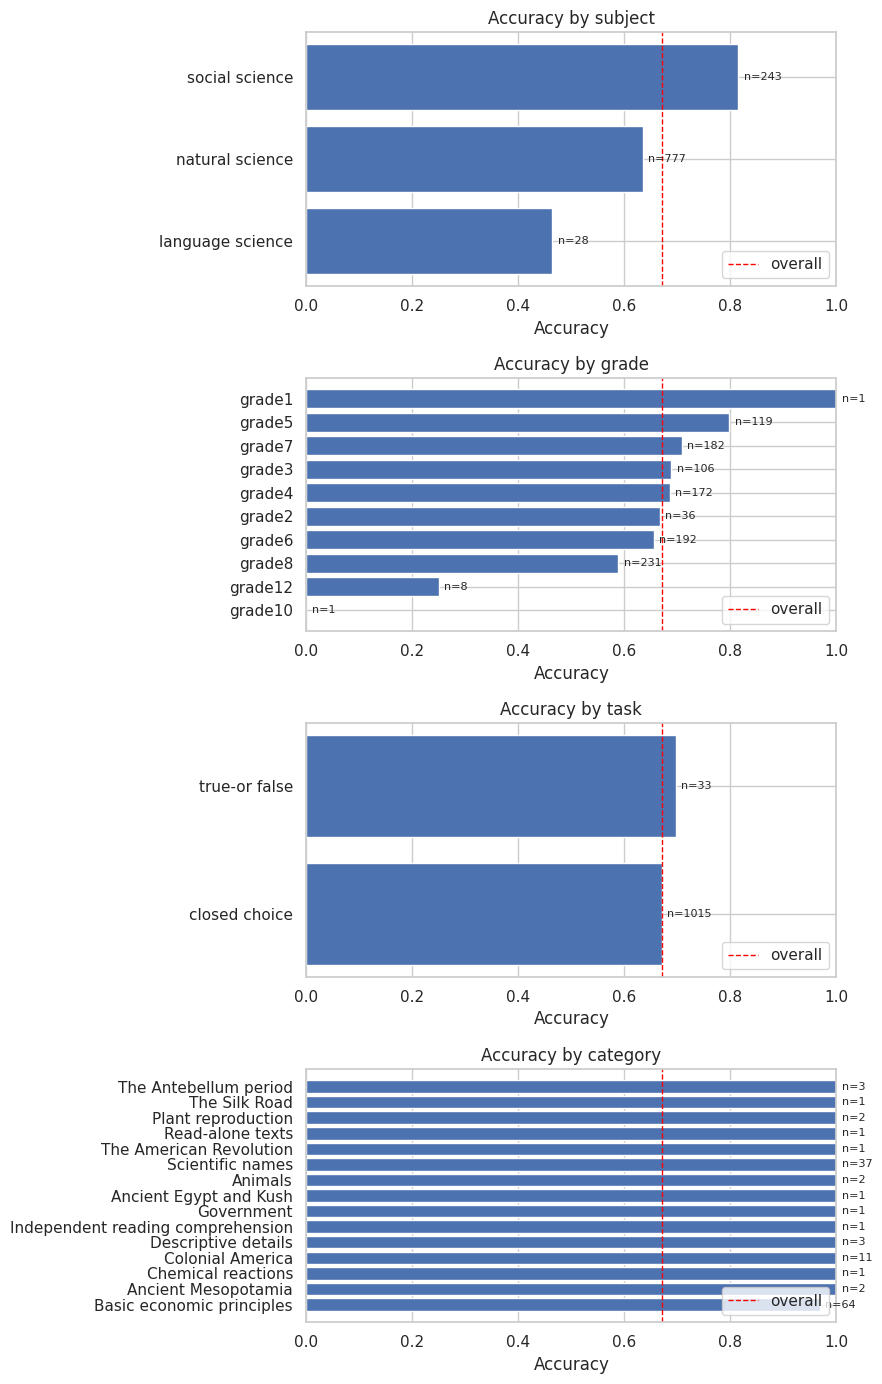

In [13]:
# ── 6b. Accuracy broken down by metadata fields ──────────────────────────────
val_results = val_df.copy()
val_results["pred"] = val_preds
val_results["correct"] = (val_results["pred"] == val_results["answer"].astype(int)).astype(int)

def plot_accuracy_by(field, ax, top_n=None):
    grouped = val_results.groupby(field).agg(
        accuracy=("correct", "mean"),
        n=("correct", "size")
    ).reset_index().sort_values("accuracy", ascending=True)
    if top_n:
        grouped = grouped.tail(top_n)
    ax.barh(grouped[field].astype(str), grouped["accuracy"])
    ax.axvline(val_results["correct"].mean(), color="red", linestyle="--", linewidth=1, label="overall")
    ax.set_xlabel("Accuracy"); ax.set_title(f"Accuracy by {field}")
    ax.set_xlim(0, 1)
    for i, (acc, n) in enumerate(zip(grouped["accuracy"], grouped["n"])):
        ax.text(acc + 0.01, i, f"n={n}", va="center", fontsize=8)
    ax.legend(loc="lower right")

# Plot for each available metadata field
fields = [f for f in ["subject", "grade", "task", "category"] if f in val_df.columns]
fig, axes = plt.subplots(len(fields), 1, figsize=(9, 3.5 * len(fields)))
if len(fields) == 1: axes = [axes]
for ax, field in zip(axes, fields):
    plot_accuracy_by(field, ax, top_n=15)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "accuracy_breakdown.png", dpi=150)
plt.show()


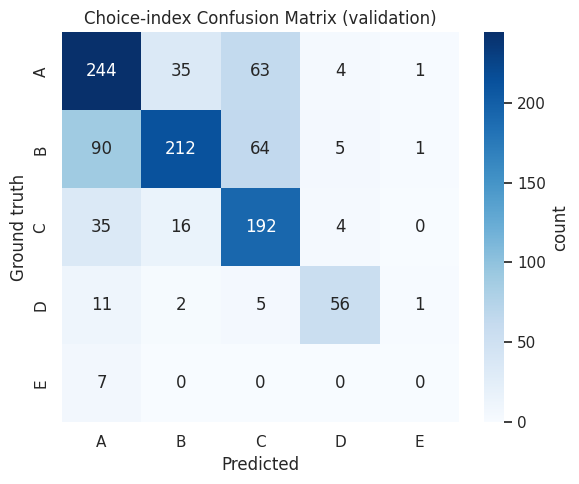

In [14]:
# ── 6c. "Confusion" between predicted and gold answer indices ────────────────
import numpy as np
max_choices = max(val_results["pred"].max(), val_results["answer"].astype(int).max()) + 1
cm = np.zeros((max_choices, max_choices), dtype=int)
for p, t in zip(val_results["pred"], val_results["answer"].astype(int)):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[CHOICE_LETTERS[i] for i in range(max_choices)],
            yticklabels=[CHOICE_LETTERS[i] for i in range(max_choices)],
            cbar_kws={"label": "count"}, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Ground truth")
ax.set_title("Choice-index Confusion Matrix (validation)")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()


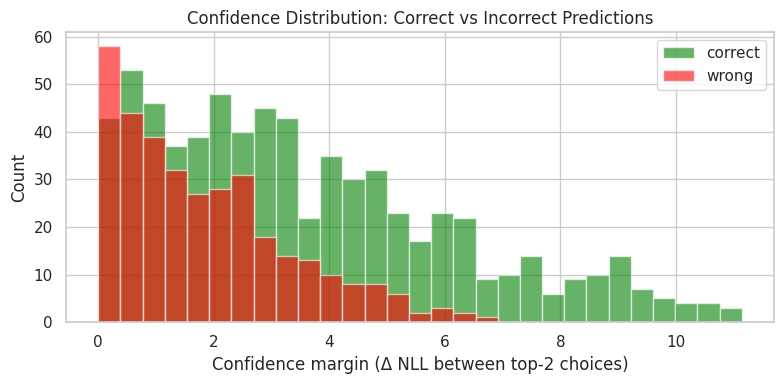

In [15]:
# ── 6d. Prediction confidence (margin between top-2 choices) ─────────────────
# Smaller NLL = higher confidence; the gap between best and 2nd-best is the margin
import numpy as np
margins, correctness = [], []
for scores, gold, pred in zip(val_scores, val_results["answer"].astype(int), val_results["pred"]):
    s = sorted(scores)
    margins.append(s[1] - s[0])  # 2nd best NLL minus best NLL → "confidence"
    correctness.append(int(pred == gold))

fig, ax = plt.subplots(figsize=(8, 4))
margins = np.array(margins); correctness = np.array(correctness)
bins = np.linspace(0, np.percentile(margins, 99), 30)
ax.hist(margins[correctness == 1], bins=bins, alpha=0.6, label="correct", color="green")
ax.hist(margins[correctness == 0], bins=bins, alpha=0.6, label="wrong",   color="red")
ax.set_xlabel("Confidence margin (Δ NLL between top-2 choices)")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution: Correct vs Incorrect Predictions")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "confidence_distribution.png", dpi=150)
plt.show()


In [16]:
# ── 6e. Summary statistics table ─────────────────────────────────────────────
summary = pd.DataFrame({
    "Metric": [
        "Validation accuracy",
        "Train examples used",
        "Trainable parameters",
        "LoRA rank",
        "Epochs",
        "Effective batch size",
        "Learning rate",
        "Image size",
        "Random baseline (4-choice)",
        "Random baseline (avg over questions)",
    ],
    "Value": [
        f"{val_acc:.4f}",
        f"{len(train_df):,}",
        f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}",
        LORA_R,
        NUM_EPOCHS,
        TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS,
        f"{LR:.2e}",
        IMG_SIZE,
        "0.2500",
        f"{(1 / val_df['num_choices']).mean():.4f}",
    ],
})
print(summary.to_string(index=False))
summary.to_csv(PLOTS_DIR / "summary_stats.csv", index=False)

# Also save a markdown table you can paste straight into a report
with open(PLOTS_DIR / "summary_stats.md", "w") as f:
    f.write(summary.to_markdown(index=False))
print(f"\nSaved tables and {len(list(PLOTS_DIR.glob('*.png')))} plots to {PLOTS_DIR}")


                              Metric     Value
                 Validation accuracy    0.6718
                 Train examples used     3,109
                Trainable parameters 5,668,864
                           LoRA rank         8
                              Epochs         2
                Effective batch size         8
                       Learning rate  3.00e-04
                          Image size       384
          Random baseline (4-choice)    0.2500
Random baseline (avg over questions)    0.3465

Saved tables and 3 plots to /kaggle/working/plots


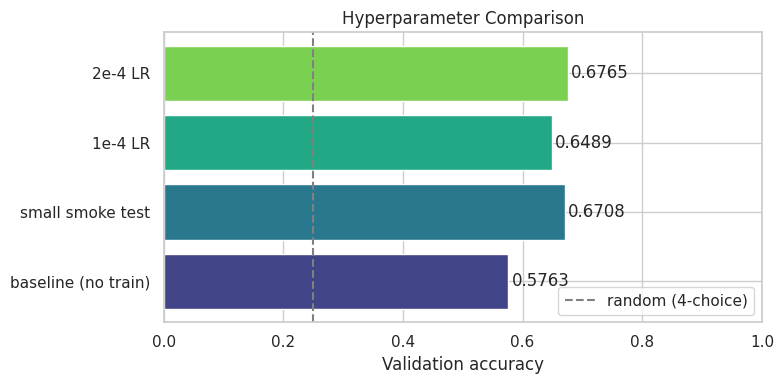

| run                 |   lora_r |   epochs |   img_size |   val_acc |   learning_rate |
|:--------------------|---------:|---------:|-----------:|----------:|----------------:|
| baseline (no train) |        0 |        0 |        384 |    0.5763 |        nan      |
| small smoke test    |        8 |        1 |        384 |    0.6708 |        nan      |
| 1e-4 LR             |        8 |        2 |        384 |    0.6489 |          0.0001 |
| 2e-4 LR             |        8 |        2 |        384 |    0.6765 |          0.0002 |


In [17]:
# ── 6f. Compare hyperparameter sweeps ────────────────────────────────────────
# Manually fill this in as you run experiments
results = pd.DataFrame([
    {"run": "baseline (no train)",  "lora_r": 0,  "epochs": 0, "img_size": 384, "val_acc": 0.5763},
    {"run": "small smoke test",     "lora_r": 8,  "epochs": 1, "img_size": 384, "val_acc": 0.6708},
    {"run": "1e-4 LR", "lora_r": 8, "epochs": 2, "img_size": 384, "learning_rate": 1e-4, "val_acc": 0.6489},
    {"run": "2e-4 LR", "lora_r": 8, "epochs": 2, "img_size": 384, "learning_rate": 2e-4, "val_acc": 0.6765}
    # add more rows as you experiment
])

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(results["run"], results["val_acc"], color=sns.color_palette("viridis", len(results)))
for i, v in enumerate(results["val_acc"]):
    ax.text(v + 0.005, i, f"{v:.4f}", va="center")
ax.set_xlabel("Validation accuracy"); ax.set_xlim(0, 1)
ax.axvline(0.25, color="gray", linestyle="--", label="random (4-choice)")
ax.set_title("Hyperparameter Comparison")
ax.legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "hyperparameter_comparison.png", dpi=150)
plt.show()

results.to_csv(PLOTS_DIR / "experiments.csv", index=False)
print(results.to_markdown(index=False))